# Telco Customer Churn Prediction
This notebook performs an end-to-end data science process to predict customer churn using XGBoost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Inspection

In [2]:
import os 
os.chdir('/Users/juanjose/Downloads/')

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Preprocessing
Converting `TotalCharges` to numeric and handling missing values.

In [5]:
# Convert TotalCharges to numeric, errors='coerce' turns blanks into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)

## 3. Exploratory Data Analysis

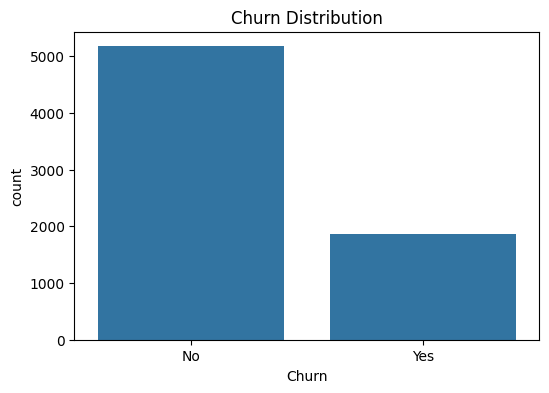

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

## 4. Feature Encoding
Using One-Hot Encoding for categorical variables and dropping the most common category.

In [7]:

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in categorical_cols:
    categorical_cols.remove('Churn')

# Use pd.get_dummies for One-Hot Encoding
# To drop the 'most common' one automatically is tricky with drop_first.
# We'll manually find the most frequent and drop it or just use drop_first=True for simplicity.
# The user asked specifically to 'drop the most common one'.
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    dummies = pd.get_dummies(df[col], prefix=col)
    # Drop the column corresponding to the mode
    mode_col = f"{col}_{mode_val}"
    if mode_col in dummies.columns:
        dummies = dummies.drop(columns=[mode_col])
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

# Encode target Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,Partner_Yes,Dependents_Yes,PhoneService_No,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_No,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,True,False,True,True,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,1889.50,0,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,True
2,0,2,53.85,108.15,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,0,45,42.30,1840.75,0,False,False,False,True,True,...,False,False,False,False,True,False,True,True,False,False
4,0,2,70.70,151.65,1,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 5. Train-Test Split
Splitting the data into training (80%) and test (20%) sets.

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

Train set shape: (5634, 30)
Test set shape: (1409, 30)


## 6. XGBoost Model Training with K-Fold CV
Using Grid Search with 5-fold cross validation to optimize F1-score.

In [14]:

param_grid = {
        'max_depth': [3, 4, 5, 6, 8, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
        'n_estimators': [100, 200, 300, 500],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
        'gamma': [0, 0.1, 0.2]
    }

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, 
                           scoring='f1', cv=skf, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-score: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 5760 candidates, totalling 28800 fits
Best Parameters: {'colsample_bytree': 0.9, 'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Best Cross-Validation F1-score: 0.5930


## 7. Out-of-Sample Validation
Evaluating the best model on the unseen test dataset.

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:


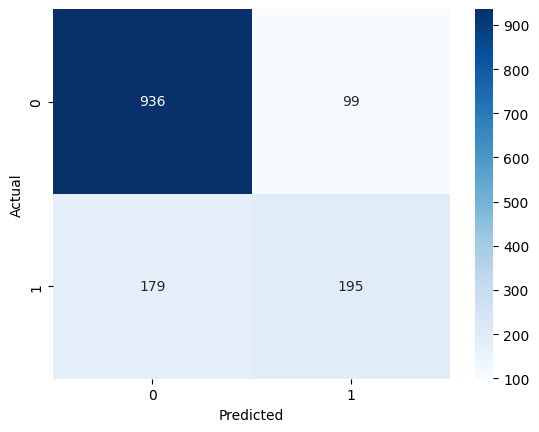

Final Test F1-score: 0.5838
Final Test ROC-AUC: 0.8436


In [11]:

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
print(f"Final Test F1-score: {f1:.4f}")
print(f"Final Test ROC-AUC: {auc:.4f}")


## 8. Feature Importance

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()